In [176]:
import pandas as pd

In [177]:
df1 = pd.read_csv('bookings.csv')

In [ ]:
df1.head()

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск


In [178]:
df2 = pd.read_csv('clients.csv')

In [ ]:
df2.head()

,client_id,company_name,tier,industry,first_booking_date
0,1,АльфаГрупп,2,Финансы,2024-09-04
1,2,БетаЛогистик,3,Ритейл,2024-02-18
2,3,ГаммаТех,3,Ритейл,2024-11-20
3,4,ДельтаФинанс,2,Логистика,2024-10-07
4,5,ЕпсилонСтрой,3,IT,2024-01-22


# Блок 1 — SQL или Python/pandas


##**Задание 1.** Рассчитай GMV и количество бронирований (`confirmed`) по каждому субпродукту помесячно за 2025 год. Ответь: какой субпродукт генерирует наибольший оборот и есть ли явная сезонность?

**GMV** считается как сумма `amount_rub` по бронированиям со статусом `confirmed`.

In [179]:
df1['booking_date'].min(), df1['booking_date'].max()

('2025-01-01', '2025-12-28')

In [180]:
df1['booking_date'] = pd.to_datetime(df1['booking_date'])

In [181]:
df1['booking_date'].dt.month

,booking_date
0,7
1,1
2,4
3,7
4,4
...,...
1959,9
1960,1
1961,3
1962,4


In [182]:
df1_2 = df1[df1['status'] =='confirmed']

In [183]:
df1_3 = df1_2.groupby([df1_2['booking_date'].dt.month, 'subproduct']).agg(gmv = ('amount_rub', 'sum'), booking_counts = ('booking_id', 'count')).reset_index().rename(columns = {'booking_date': 'month'})

In [184]:
df1_3

,month,subproduct,gmv,booking_counts
0,1,avia,3465491.28,43
1,1,hotel,1658369.43,37
2,1,taxi,19315.53,11
3,1,train,398173.18,26
4,2,avia,4821583.41,60
5,2,hotel,2276832.71,48
6,2,taxi,31438.68,15
7,2,train,328787.09,26
8,3,avia,5966560.92,76
9,3,hotel,2748759.23,54


In [185]:
df1_3.groupby('subproduct').agg(sum_gmv = ('gmv', 'sum')).sort_values('sum_gmv', ascending=False)

,sum_gmv
subproduct,
avia,51305843.40
hotel,28495450.26
train,4534020.63
taxi,367063.63


Наибольший оборот - avia

In [186]:
pivot_gmv = df1_3.pivot(index='month', columns='subproduct', values='gmv')

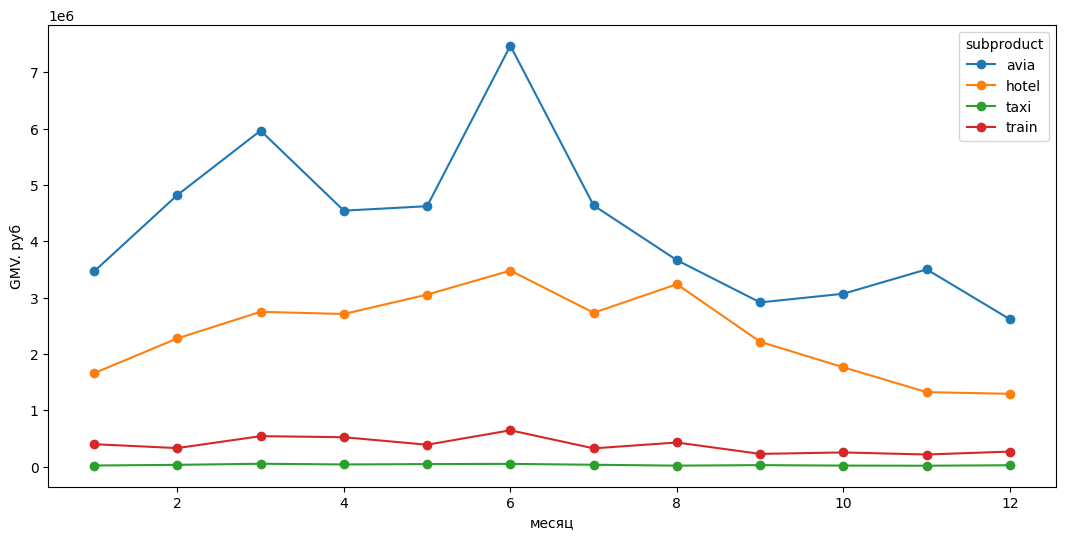

In [187]:
import matplotlib.pyplot as plt

pivot_gmv.plot(kind='line', marker='o', figsize=(13, 6))

plt.xlabel('месяц')
plt.ylabel('GMV. руб')

plt.legend(title='subproduct')

plt.show()

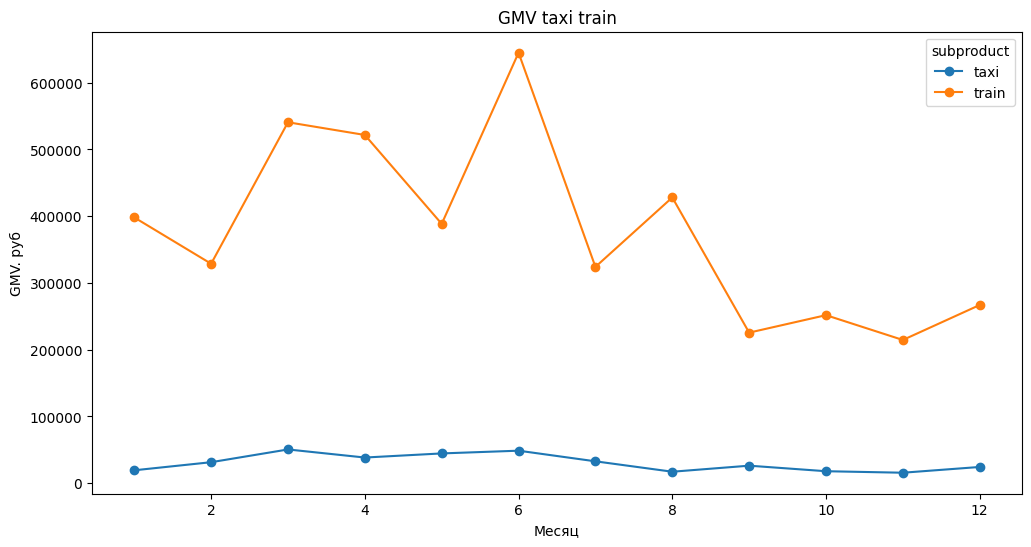

In [188]:
pivot_gmv[['taxi', 'train']].plot(kind='line', marker='o', figsize=(12, 6))
plt.title('GMV taxi train')
plt.xlabel('Месяц')
plt.ylabel('GMV. руб')
plt.show()

Выбран линейный тип графика т.к. он наглядно описывает динамику GMV в зависимости от месяца

Явная сезонность присутствует у avia и hotel, с пиком в июне (высокий сезон отпусков) и спадом к концу года

##**Задание 2.** Найди топ-10 клиентов по GMV за весь 2025 год. Для каждого покажи: GMV, количество бронирований, средний чек, тир клиента, отрасль.

In [33]:
df1


,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск
...,...,...,...,...,...,...,...,...,...
1959,1960,33,hotel,2025-09-11,2025-09-14,75960.62,confirmed,Екатеринбург,Санкт-Петербург
1960,1961,37,taxi,2025-01-01,2025-01-22,422.99,confirmed,Москва,Екатеринбург
1961,1962,45,train,2025-03-10,2025-03-21,21255.24,confirmed,Казань,Новосибирск
1962,1963,37,avia,2025-04-10,2025-04-12,80357.36,cancelled,Казань,Санкт-Петербург


In [34]:
df2_1 = pd.merge(df1, df2, on = 'client_id', how = 'inner')

In [35]:
df2_1

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to,company_name,tier,industry,first_booking_date
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи,АльфаГрупп,2,Финансы,2024-09-04
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург,ЕпсилонСтрой,3,IT,2024-01-22
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва,ТехноПром,3,Ритейл,2024-11-18
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань,СигмаЭнерго,3,Ритейл,2024-06-13
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск,ТехноПром,3,Ритейл,2024-11-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,1960,33,hotel,2025-09-11,2025-09-14,75960.62,confirmed,Екатеринбург,Санкт-Петербург,ЮгКомпани,1,Строительство,2024-10-15
1960,1961,37,taxi,2025-01-01,2025-01-22,422.99,confirmed,Москва,Екатеринбург,МегаСтрой,2,Логистика,2024-11-11
1961,1962,45,train,2025-03-10,2025-03-21,21255.24,confirmed,Казань,Новосибирск,СтандартХолд,2,Ритейл,2024-01-20
1962,1963,37,avia,2025-04-10,2025-04-12,80357.36,cancelled,Казань,Санкт-Петербург,МегаСтрой,2,Логистика,2024-11-11


In [173]:
top10 = df2_1[df2_1['status'] == 'confirmed'].groupby('client_id').agg(gmv = ('amount_rub', 'sum'), bookings_count = ('booking_id', 'count'), avg_pay = ('amount_rub', 'mean'), tier = ('tier', 'first'), industry = ('industry', 'first')).sort_values('gmv', ascending=False).head(10).round({'avg_pay': 0})

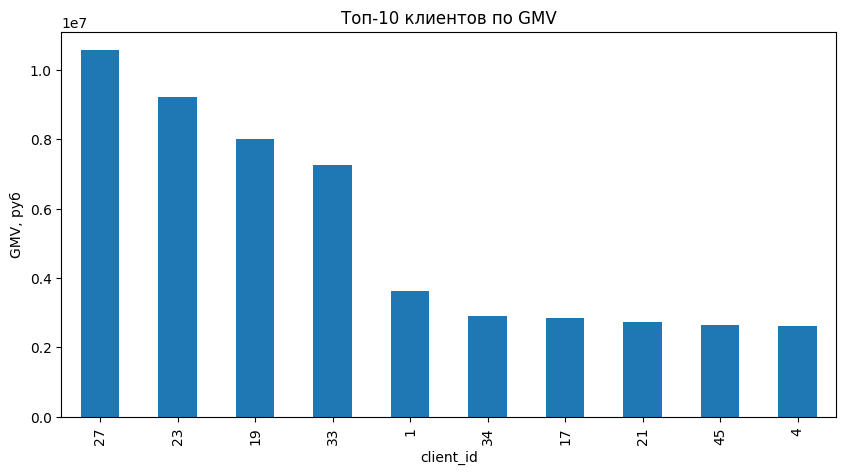

In [189]:
top10['gmv'].plot(kind='bar', figsize=(10, 5))
plt.xlabel('client_id')
plt.ylabel('GMV, руб')
plt.title('Топ-10 клиентов по GMV')
plt.show()

Выбран тип графика - столбчатая диаграмма т.к. он хорошо показывает разницу между топ-10 клиентами по GMV

##**Задание 3.** Посчитай долю отмен (`cancelled / всего`) по субпродуктам. Укажи, если есть субпродукт с заметно более высокой долей отмен, и предложи гипотезу — почему.

In [5]:
df1

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск
...,...,...,...,...,...,...,...,...,...
1959,1960,33,hotel,2025-09-11,2025-09-14,75960.62,confirmed,Екатеринбург,Санкт-Петербург
1960,1961,37,taxi,2025-01-01,2025-01-22,422.99,confirmed,Москва,Екатеринбург
1961,1962,45,train,2025-03-10,2025-03-21,21255.24,confirmed,Казань,Новосибирск
1962,1963,37,avia,2025-04-10,2025-04-12,80357.36,cancelled,Казань,Санкт-Петербург


In [17]:
df3_1 = df1[df1['status'] == 'cancelled'].groupby('subproduct').agg(count_cancelled = ('status', 'count')).reset_index()

In [18]:
df3_2 = df1.groupby('subproduct').agg(count_all = ('status', 'count')).reset_index()

In [19]:
df3_3 = pd.merge(df3_1, df3_2, on = 'subproduct', how = 'inner')

In [30]:
df3_3['ratio'] = (df3_3['count_cancelled'] / df3_3['count_all']).round(4) * 100

In [31]:
df3_3

,subproduct,count_cancelled,count_all,ratio
0,avia,117,767,15.25
1,hotel,83,623,13.32
2,taxi,21,195,10.77
3,train,52,379,13.72


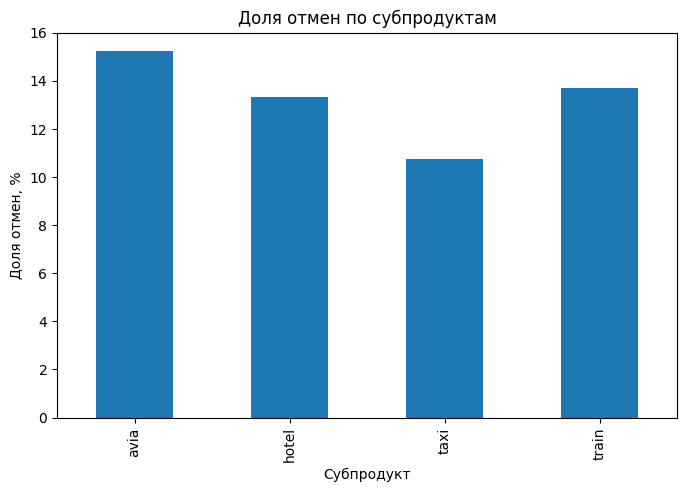

In [190]:
df3_3.plot(x='subproduct', y='ratio', kind='bar', figsize=(8, 5), legend=False)
plt.xlabel('Субпродукт')
plt.ylabel('Доля отмен, %')
plt.title('Доля отмен по субпродуктам')
plt.show()

Выбран тип графика - столбчатая диаграмма т.к. он хорошо визуализирует разницу между близкими значениями разных субпродуктов

Доля отмен по субпродуктам находится в диапазоне 10.8%–15.3% и не показывает резких аномалий. При этом avia демонстрирует самую высокую долю отмен (15.25%), заметно опережая taxi с наименьшей долей (10.77%).
У avia самый длинный горизонт планирования - билеты часто покупают заранее, что увеличивает вероятность изменения планов клиента до даты вылета. Taxi, напротив, заказывают под уже подтверждённую потребность, поэтому отмены там минимальны.

# Блок 2 — Бизнес-анализ

##**Задание 4.** Есть гипотеза: клиенты тира 1 бронируют более дорогие продукты, но реже, чем клиенты тира 3. Проверь гипотезу данными. Подтвердилась ли она? Что ещё интересного ты заметил(-а) при анализе тиров?

In [39]:
df1.head()

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск


In [40]:
df2.head()

,client_id,company_name,tier,industry,first_booking_date
0,1,АльфаГрупп,2,Финансы,2024-09-04
1,2,БетаЛогистик,3,Ритейл,2024-02-18
2,3,ГаммаТех,3,Ритейл,2024-11-20
3,4,ДельтаФинанс,2,Логистика,2024-10-07
4,5,ЕпсилонСтрой,3,IT,2024-01-22


In [41]:
df4 = pd.merge(df1, df2, on = 'client_id', how = 'inner')

In [42]:
df4

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to,company_name,tier,industry,first_booking_date
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи,АльфаГрупп,2,Финансы,2024-09-04
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург,ЕпсилонСтрой,3,IT,2024-01-22
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва,ТехноПром,3,Ритейл,2024-11-18
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань,СигмаЭнерго,3,Ритейл,2024-06-13
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск,ТехноПром,3,Ритейл,2024-11-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,1960,33,hotel,2025-09-11,2025-09-14,75960.62,confirmed,Екатеринбург,Санкт-Петербург,ЮгКомпани,1,Строительство,2024-10-15
1960,1961,37,taxi,2025-01-01,2025-01-22,422.99,confirmed,Москва,Екатеринбург,МегаСтрой,2,Логистика,2024-11-11
1961,1962,45,train,2025-03-10,2025-03-21,21255.24,confirmed,Казань,Новосибирск,СтандартХолд,2,Ритейл,2024-01-20
1962,1963,37,avia,2025-04-10,2025-04-12,80357.36,cancelled,Казань,Санкт-Петербург,МегаСтрой,2,Логистика,2024-11-11


In [51]:
df4_1 = df4[df4['tier'] == 1][['client_id', 'booking_date', 'amount_rub', 'tier']].sort_values(['client_id', 'booking_date'], ascending=True)

In [52]:
df4_1.head()

,client_id,booking_date,amount_rub,tier
1789,19,2025-01-04,43478.56,1
1311,19,2025-01-10,26749.71,1
358,19,2025-01-12,23021.73,1
1060,19,2025-01-14,183337.31,1
887,19,2025-01-17,135807.14,1


In [53]:
df4_3 = df4[df4['tier'] == 3][['client_id', 'booking_date', 'amount_rub', 'tier']].sort_values(['client_id', 'booking_date'], ascending=True)

In [54]:
df4_3.head()

,client_id,booking_date,amount_rub,tier
533,2,2025-02-08,11813.46,3
704,2,2025-03-26,1218.31,3
1198,2,2025-06-20,16194.15,3
69,2,2025-07-20,7776.24,3
1900,2,2025-08-09,12907.37,3


In [55]:
df4_1['booking_date'] = pd.to_datetime(df4_1['booking_date'])

In [56]:
df4_3['booking_date'] = pd.to_datetime(df4_3['booking_date'])

In [57]:
df4_1['days_since_previous_booking'] = df4_1.groupby('client_id')['booking_date'].diff().dt.days

In [58]:
df4_3['days_since_previous_booking'] = df4_3.groupby('client_id')['booking_date'].diff().dt.days

In [59]:
df4_1

,client_id,booking_date,amount_rub,tier,days_since_previous_booking
1789,19,2025-01-04,43478.56,1,NaN
1311,19,2025-01-10,26749.71,1,6.0
358,19,2025-01-12,23021.73,1,2.0
1060,19,2025-01-14,183337.31,1,2.0
887,19,2025-01-17,135807.14,1,3.0
...,...,...,...,...,...
1580,33,2025-12-08,30736.58,1,1.0
1752,33,2025-12-08,582.27,1,0.0
22,33,2025-12-17,1083.90,1,9.0
89,33,2025-12-24,135251.41,1,7.0


In [76]:
df4_1['average_days_since_prev'] = df4_1.groupby('client_id')['days_since_previous_booking'].transform('mean')

In [77]:
df4_1['average_amount_rub'] = df4_1.groupby('client_id')['amount_rub'].transform('mean')

In [78]:
df4_1

,client_id,booking_date,amount_rub,tier,days_since_previous_booking,average_days_since_prev,average_amount_rub
1789,19,2025-01-04,43478.56,1,NaN,3.240741,83116.599083
1311,19,2025-01-10,26749.71,1,6.0,3.240741,83116.599083
358,19,2025-01-12,23021.73,1,2.0,3.240741,83116.599083
1060,19,2025-01-14,183337.31,1,2.0,3.240741,83116.599083
887,19,2025-01-17,135807.14,1,3.0,3.240741,83116.599083
...,...,...,...,...,...,...,...
1580,33,2025-12-08,30736.58,1,1.0,3.849462,88978.416702
1752,33,2025-12-08,582.27,1,0.0,3.849462,88978.416702
22,33,2025-12-17,1083.90,1,9.0,3.849462,88978.416702
89,33,2025-12-24,135251.41,1,7.0,3.849462,88978.416702


In [97]:
print(df4_1['average_days_since_prev'].mean().round(0))
print(round(df4_1['average_days_since_prev'].median()))
print(df4_1['average_amount_rub'].mean().round(0))
print(round(df4_1['average_amount_rub'].median()),0)

3.0
3
82848.0
81717 0


In [79]:
df4_3['average_days_since_prev'] = df4_3.groupby('client_id')['days_since_previous_booking'].transform('mean')

In [80]:
df4_3['average_amount_rub'] = df4_3.groupby('client_id')['amount_rub'].transform('mean')

In [81]:
df4_3

,client_id,booking_date,amount_rub,tier,days_since_previous_booking,average_days_since_prev,average_amount_rub
533,2,2025-02-08,11813.46,3,NaN,61.000000,17983.210
704,2,2025-03-26,1218.31,3,46.0,61.000000,17983.210
1198,2,2025-06-20,16194.15,3,86.0,61.000000,17983.210
69,2,2025-07-20,7776.24,3,30.0,61.000000,17983.210
1900,2,2025-08-09,12907.37,3,20.0,61.000000,17983.210
...,...,...,...,...,...,...,...
1214,50,2025-06-13,621.27,3,1.0,12.428571,25822.544
1697,50,2025-06-17,8917.47,3,4.0,12.428571,25822.544
1501,50,2025-06-19,3351.34,3,2.0,12.428571,25822.544
705,50,2025-06-21,52215.37,3,2.0,12.428571,25822.544


In [98]:
print(df4_3['average_days_since_prev'].mean().round(0))
print(round(df4_3['average_days_since_prev'].median()))
print(df4_3['average_amount_rub'].mean().round(0))
print(round(df4_3['average_amount_rub'].median()))

16.0
14
29451.0
29578 0


Tier 1 клиенты имеют более дорогие брони и делают их чаще => гипотеза не подтверждена

##**Задание 5.** Найди клиентов, у которых в первом полугодии 2025 года (январь–июнь) были бронирования, а во втором (июль–декабрь) — не было ни одного подтверждённого. Это потенциальный отток (churn). Сколько таких клиентов? Каков их суммарный GMV за H1? Какого они тира?

In [100]:
df5 = pd.merge(df1, df2, on = 'client_id', how = 'inner')

In [102]:
df5.head()

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to,company_name,tier,industry,first_booking_date
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи,АльфаГрупп,2,Финансы,2024-09-04
1,2,5,train,2025-01-10,2025-01-17,14108.65,confirmed,Москва,Санкт-Петербург,ЕпсилонСтрой,3,IT,2024-01-22
2,3,36,hotel,2025-04-14,2025-04-29,34857.82,cancelled,Екатеринбург,Москва,ТехноПром,3,Ритейл,2024-11-18
3,4,18,avia,2025-07-17,2025-07-18,24844.33,confirmed,Екатеринбург,Казань,СигмаЭнерго,3,Ритейл,2024-06-13
4,5,36,hotel,2025-04-24,2025-05-09,58959.96,confirmed,Уфа,Новосибирск,ТехноПром,3,Ритейл,2024-11-18


In [103]:
df5['booking_date'] = pd.to_datetime(df5['booking_date'])

In [127]:
df5_1 = df5[(df5['status'] == 'confirmed') & (df5['booking_date'].dt.month <= 6)].groupby('client_id').agg(booking_count_h1 = ('booking_date', 'count'), tier=('tier', 'first')).reset_index()

In [131]:
df5_2 = df5[(df5['status'] == 'confirmed') & (df5['booking_date'].dt.month > 6)].groupby('client_id').agg(booking_count_h2 = ('booking_date', 'count')).reset_index()

In [136]:
df5_3 = pd.merge(df5_1, df5_2, on = 'client_id', how = 'left')

In [144]:
df5_3[(df5_3['booking_count_h1'] != 0) & (df5_3['booking_count_h2'].isna())].agg(count_churn=('client_id', 'count'), tiers=('tier', lambda x: list(x.unique()))).reset_index()

,index,client_id,tier
0,count_churn,16.0,NaN
1,tiers,NaN,"[3, 2]"


In [145]:
churn_ids = df5_3[(df5_3['booking_count_h1'] != 0) & (df5_3['booking_count_h2'].isna())]['client_id']

In [150]:
df5[(df5['status'] == 'confirmed') & (df5['booking_date'].dt.month <= 6) & df5['client_id'].isin(churn_ids)].agg(gmv_churn_h1 = ('amount_rub', 'sum')).reset_index()

,index,amount_rub
0,gmv_churn_h1,17510111.8


Churn клиентов 16 - tier 2, 3. GMV = 17 510 111.8

# Блок 3 — Когортный анализ

##**Задание 6.** «Новый клиент» — тот, у кого `first_booking_date` приходится на 2025 год.

Для каждого нового клиента определи месяц первой активности в 2025 году (когорту). Затем для каждой когорты покажи, сколько клиентов оставались активными в каждом из последующих месяцев (были хотя бы одно `confirmed` бронирование). Это retention-таблица.

Интерпретируй: есть ли когорты, которые удерживаются лучше других?

In [170]:
df6 = pd.merge(df1, df2, on = 'client_id', how = 'outer')

In [171]:
df6

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to,company_name,tier,industry,first_booking_date
0,1,1,train,2025-07-18,2025-07-20,3420.52,confirmed,Новосибирск,Сочи,АльфаГрупп,2,Финансы,2024-09-04
1,18,1,hotel,2025-11-12,2025-11-22,70732.85,confirmed,Новосибирск,Уфа,АльфаГрупп,2,Финансы,2024-09-04
2,26,1,avia,2025-07-07,2025-07-21,54725.88,confirmed,Санкт-Петербург,Сочи,АльфаГрупп,2,Финансы,2024-09-04
3,43,1,avia,2025-12-26,2026-01-13,67069.88,confirmed,Санкт-Петербург,Москва,АльфаГрупп,2,Финансы,2024-09-04
4,52,1,avia,2025-07-25,2025-08-09,93772.65,confirmed,Уфа,Новосибирск,АльфаГрупп,2,Финансы,2024-09-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,1555,50,train,2025-05-26,2025-06-12,9670.85,cancelled,Сочи,Казань,ЭкспертКо,3,Логистика,2024-12-16
1960,1648,50,avia,2025-06-24,2025-07-02,72593.39,confirmed,Казань,Уфа,ЭкспертКо,3,Логистика,2024-12-16
1961,1649,50,hotel,2025-04-28,2025-05-19,22474.04,confirmed,Сочи,Санкт-Петербург,ЭкспертКо,3,Логистика,2024-12-16
1962,1698,50,hotel,2025-06-17,2025-07-05,8917.47,confirmed,Новосибирск,Уфа,ЭкспертКо,3,Логистика,2024-12-16


In [172]:
df6['first_booking_date'].min(), df6['first_booking_date'].max()

('2024-01-08', '2024-12-22')

В first_booking_date нет 2025 года

# Блок 5 — Выводы

##**Задание 8.** Напиши 3–5 ключевых наблюдений из всего анализа. Для каждого сформулируй по структуре:

- **Что вижу:** факт из данных
- **Почему важно:** бизнес-значение
- **Что дальше:** что ты бы предложил(-а) проверить или сделать

1. **Сезонность и доминирование авиабилетов**
   - Что вижу: Продукт avia генерирует более 51 млн руб. GMV (более 60% общего оборота), при этом наблюдается четкий пик спроса в июне и спад к концу года.
   - Почему важно: Бизнес сильно зависит от одного продукта и подвержен сезонным колебаниям, что создает риски в низкий сезон.
   - Что дальше: Разработать маркетинговые акции для отелей и ж/д в межсезонье.

2. **Поведение клиентов Tier 1 vs Tier 3**
   - Что вижу: Клиенты Tier 1 бронируют чаще (раз в 3 дня против 16 дней у Tier 3) и на значительно большие суммы (83 тыс. руб. против 29 тыс. руб. в среднем).
   - Почему важно: Гипотеза о том, что Tier 1 бронирует реже, опровергнута. Это наиболее лояльный и доходный сегмент, приносящий основной объем выручки.
   - Что дальше: Сосредоточить программу лояльности на удержании Tier 1 и проанализировать, за счет каких потребностей можно перевести клиентов Tier 2/3 в более высокий тир.

3. **Потенциальный отток во втором полугодии**
   - Что вижу: Выявлено 16 клиентов (Tier 2 и 3), которые делали заказы в H1, но не имели подтвержденных бронирований в H2. Потерянный GMV составил более 17.5 млн руб.
   - Почему важно: Это значительная сумма (около 20% от годового оборота), потеря которой напрямую замедляет рост компании.
   - Что дальше: Провести опрос среди этих 16 клиентов для выяснения причин ухода и предложить им персональные условия (скидки или бонусы) для возвращения.